<a href="https://colab.research.google.com/github/codewithdebuu/OpenCV/blob/main/DS_1st_%26_2nd_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
import numpy as np
import math
import matplotlib.pyplot as plt
import os

In [11]:
# Upload file from PC
Uploaded = files.upload()

# Get uploaded file name and content
print()
for fn in Uploaded.keys():
    print(
        'User uploaded file "{name}" with length {length} bytes'.format(
            name=fn,
            length=len(Uploaded[fn])
        )
    )


Saving professor.jpg to professor.jpg
Saving wolf_1.png to wolf_1.png
Saving wolf_3.jpg to wolf_3.jpg

User uploaded file "professor.jpg" with length 148837 bytes
User uploaded file "wolf_1.png" with length 131772 bytes
User uploaded file "wolf_3.jpg" with length 172415 bytes


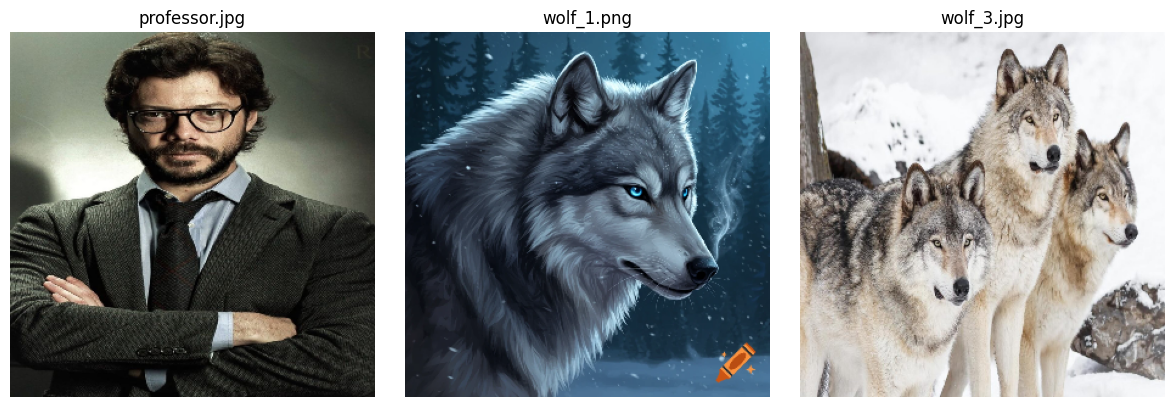

In [12]:
# Get file names
file_list = list(Uploaded.keys())

# Max 3 images per row
cols = 3
rows = math.ceil(len(file_list) / cols)

# Create figure
plt.figure(figsize=(12, rows * 4))

# Show images
for i, fn in enumerate(file_list):

    # Read image
    img = cv2.imread(fn)

    # Fixed size
    img = cv2.resize(img, (300, 300))

    # BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Position image
    plt.subplot(rows, cols, i + 1)

    # Show image
    plt.imshow(img)

    # File name
    plt.title(fn)

    # Hide axis
    plt.axis("off")

# Remove empty spaces
plt.tight_layout()

# Display
plt.show()

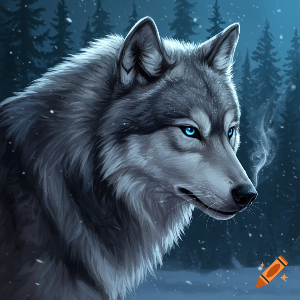

In [13]:
# Select 2nd image
img_2 = cv2.imread(file_list[1])
img_2 = cv2.resize(img_2, (300,300))

cv2_imshow(img_2)

# Now we will work on this image. **Let's get started!**

# Convert to **Grayscale**

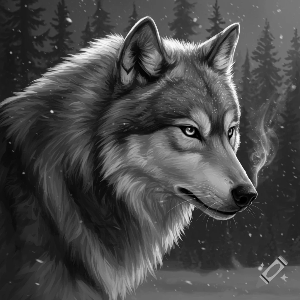

In [14]:
img_2_gray = cv2.cvtColor(img_2, cv2.COLOR_BGR2GRAY)
cv2_imshow(img_2_gray)

# **Face Detection**


professor.jpg


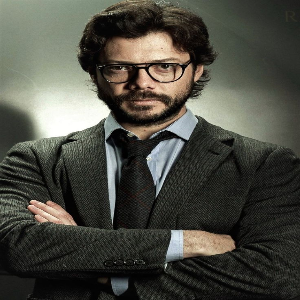

In [15]:
img_1 = cv2.imread(file_list[0])
img_1_resize = cv2.resize(img_1, (300,300))
img_1_org = img_1_resize.copy()
print()
print(file_list[0])
cv2_imshow(img_1_org)

# CascadeClassifier(**Haarcascade_frontalface**)

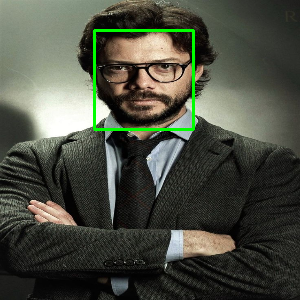

In [16]:
# Load face detector model
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Convert image to gray
gray = cv2.cvtColor(img_1_resize, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Loop through found faces
for (x, y, w, h) in faces:

    # Draw rectangle (image, start point, end point, color, thickness)
    cv2.rectangle(
        img_1_resize,
        (x, y),       # Start point (top-left)
        (x+w, y+h),   # End point (bottom-right)
        (0, 255, 0),  # Green
        2             # Border width
    )

# Show result
cv2_imshow(img_1_resize)

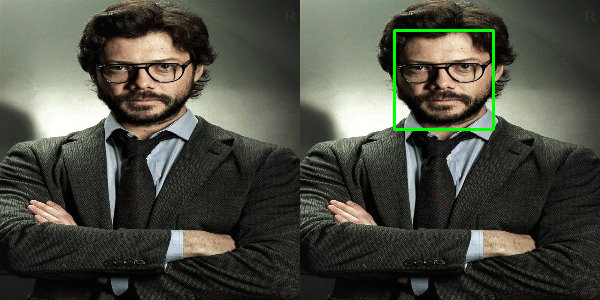

In [17]:
# Show both image in Horizontal
img_horizontal = cv2.hconcat([img_1_org, img_1_resize])

# Show
cv2_imshow(img_horizontal)

# Circle Marking

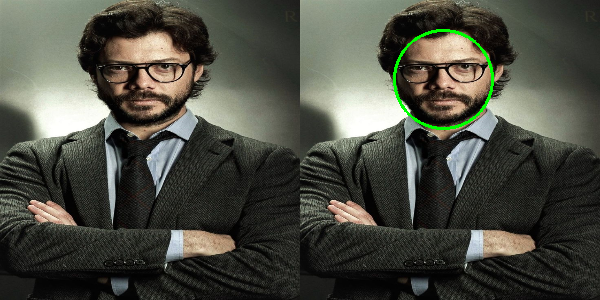

In [23]:
img_1 = cv2.imread(file_list[0])  # 3rd Image.

img_1_resize = cv2.resize(img_1, (300,300))
img_1_org = img_1_resize.copy()
print()


# Load face detector model
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Convert image to gray
gray = cv2.cvtColor(img_1_resize, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Draw CIRCLE instead of rectangle
for (x, y, w, h) in faces:

    # Face center X
    center_x = x + w // 2

    # Face center Y
    center_y = y + h // 2

    # Circle size
    radius = int(max(w, h) / 2)

    # Draw circle
    cv2.circle(
        img_1_resize,
        (center_x, center_y), # Center point
        radius,               # Radius
        (0, 255, 0),          # Green
        2                     # Border width
    )


# Show both image in Horizontal
img_horizontal = cv2.hconcat([img_1_org, img_1_resize])

# Show
cv2_imshow(img_horizontal)

# Let's try it with animal face.

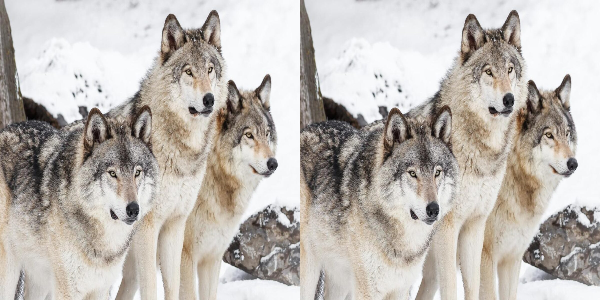

In [19]:
img_1 = cv2.imread(file_list[2])  # 3rd Image.

img_1_resize = cv2.resize(img_1, (300,300))
img_1_org = img_1_resize.copy()
print()


# Load face detector model
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Convert image to gray
gray = cv2.cvtColor(img_1_resize, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Loop through found faces
for (x, y, w, h) in faces:

    # Draw rectangle (image, start point, end point, color, thickness)
    cv2.rectangle(
        img_1_resize,
        (x, y),
        (x+w, y+h),
        (0, 255, 0),  # Green
        2             # Border width
    )



# Show both image in Horizontal
img_horizontal = cv2.hconcat([img_1_org, img_1_resize])

# Show
cv2_imshow(img_horizontal)

# Alas! This model can't detect animal faces.

# Edge Detection ( **Canny** )

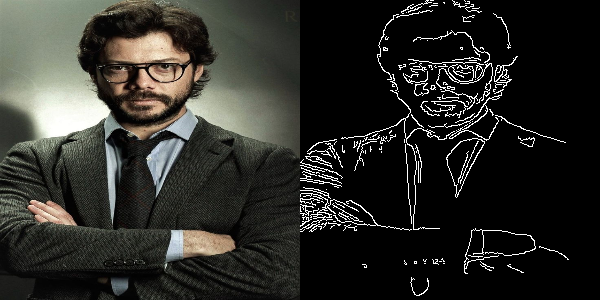

In [38]:
# Find edges
edges = cv2.Canny(img_1_org, 150, 300)

# Gray → BGR
edges_cvt = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

# Combine horizontal
img_horizontal = cv2.hconcat([img_1_org, edges_cvt])

# Show
cv2_imshow(img_horizontal)


# Edges From Colorfull image

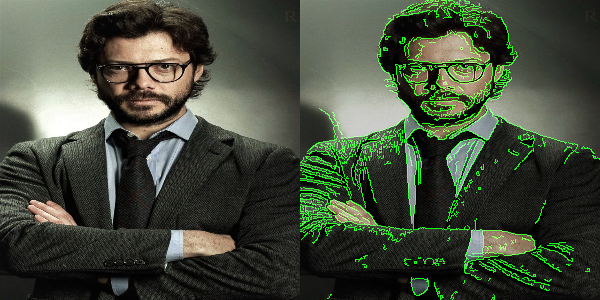

In [41]:
# Detect edges from image
edges = cv2.Canny(
    img_1_org,   # Input image
    100,         # Low threshold
    200          # High threshold
)

# Convert gray edge image to BGR
edge_colored = cv2.cvtColor(
    edges,
    cv2.COLOR_GRAY2BGR
)

# Change edge pixels to green
edge_colored[
    edges != 0
] = [
    0,    # Blue
    255,  # Green
    0     # Red
]

# Merge original image + colored edge
result = cv2.addWeighted(

    img_1_org,   # Original image
    0.8,

    edge_colored,
    1,

    0
)

# Combine images horizontally
img_horizontal = cv2.hconcat(
    [img_1_org, result]
)

# Show final image
cv2_imshow(img_horizontal)

# **Thank You!!**